In [28]:
import warnings
warnings.filterwarnings("ignore")

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import os
import numpy as np

In [30]:
df= pd.read_csv("filtered_data_2.csv").dropna()

df

,Unnamed: 0,time_UTC,observed_data,forecast_data,offset,x,y,station_id,time_UTC_dt
0,3153.0,9/25/2022 1:00,0.145,-0.239,-0.384,-89.2465,29.133800,1.545000e+03,0.0
1,3154.0,9/25/2022 2:00,0.206,-0.204,-0.410,-89.2465,29.133800,1.545000e+03,60.0
2,3155.0,9/25/2022 3:00,0.276,-0.163,-0.439,-89.2465,29.133800,1.545000e+03,120.0
3,3156.0,9/25/2022 4:00,0.355,-0.118,-0.473,-89.2465,29.133800,1.545000e+03,180.0
4,3157.0,9/25/2022 5:00,0.335,-0.093,-0.428,-89.2465,29.133800,1.545000e+03,240.0
...,...,...,...,...,...,...,...,...,...
41579,17996.0,10/1/2022 19:00,4.410,4.972,0.562,-70.3817,43.461628,4.327420e+14,9720.0
41580,17997.0,10/1/2022 20:00,4.540,4.698,0.158,-70.3817,43.461628,4.327420e+14,9780.0
41581,17998.0,10/1/2022 21:00,3.760,3.339,-0.421,-70.3817,43.461628,4.327420e+14,9840.0
41582,17999.0,10/1/2022 22:00,2.030,1.235,-0.795,-70.3817,43.461628,4.327420e+14,9900.0


In [31]:
df['station_id'].nunique()

263

In [32]:
# df_plotter = df.drop(['Unnamed: 0','forecast_data','observed_data','time_UTC_dt'], axis=1)

# plotter_pivot_df = df_plotter.pivot_table(values='offset', index='time_UTC', columns='station_id', aggfunc='first')

# output_dir = 'Gauge stations plots'

# if not os.path.exists(output_dir):
#    os.makedirs(output_dir)

# for column in plotter_pivot_df.columns:
#     plt.figure()
#     plt.plot(plotter_pivot_df[column])
#     plt.title(f'{column}')
#     plt.xlabel('Time')
#     plt.xticks([])
#     plt.ylabel('Offset')
#     plt.savefig(f'{output_dir}/{column}_time_series_plot.png')
#     plt.close()

# print('Time series plots saved successfully.')

In [33]:
df_plotter = df.drop(['Unnamed: 0','forecast_data','observed_data','time_UTC_dt'], axis=1)

plotter_pivot_df = df_plotter.pivot_table(values='offset', index='time_UTC', columns='station_id', aggfunc='first')

In [35]:
station_counts = df['station_id'].value_counts()

df = df[df['station_id'].isin(station_counts[station_counts == 167].index)].reset_index()

df

,index,Unnamed: 0,time_UTC,observed_data,forecast_data,offset,x,y,station_id,time_UTC_dt
0,0,3153.0,9/25/2022 1:00,0.145,-0.239,-0.384,-89.2465,29.133800,1.545000e+03,0.0
1,1,3154.0,9/25/2022 2:00,0.206,-0.204,-0.410,-89.2465,29.133800,1.545000e+03,60.0
2,2,3155.0,9/25/2022 3:00,0.276,-0.163,-0.439,-89.2465,29.133800,1.545000e+03,120.0
3,3,3156.0,9/25/2022 4:00,0.355,-0.118,-0.473,-89.2465,29.133800,1.545000e+03,180.0
4,4,3157.0,9/25/2022 5:00,0.335,-0.093,-0.428,-89.2465,29.133800,1.545000e+03,240.0
...,...,...,...,...,...,...,...,...,...,...
31391,41579,17996.0,10/1/2022 19:00,4.410,4.972,0.562,-70.3817,43.461628,4.327420e+14,9720.0
31392,41580,17997.0,10/1/2022 20:00,4.540,4.698,0.158,-70.3817,43.461628,4.327420e+14,9780.0
31393,41581,17998.0,10/1/2022 21:00,3.760,3.339,-0.421,-70.3817,43.461628,4.327420e+14,9840.0
31394,41582,17999.0,10/1/2022 22:00,2.030,1.235,-0.795,-70.3817,43.461628,4.327420e+14,9900.0


In [36]:
df['station_id'].nunique()

188

In [37]:
df_filtered = df[df['station_id'] != 85670.0]

df['station_id'] = df_filtered['station_id'].astype(str)

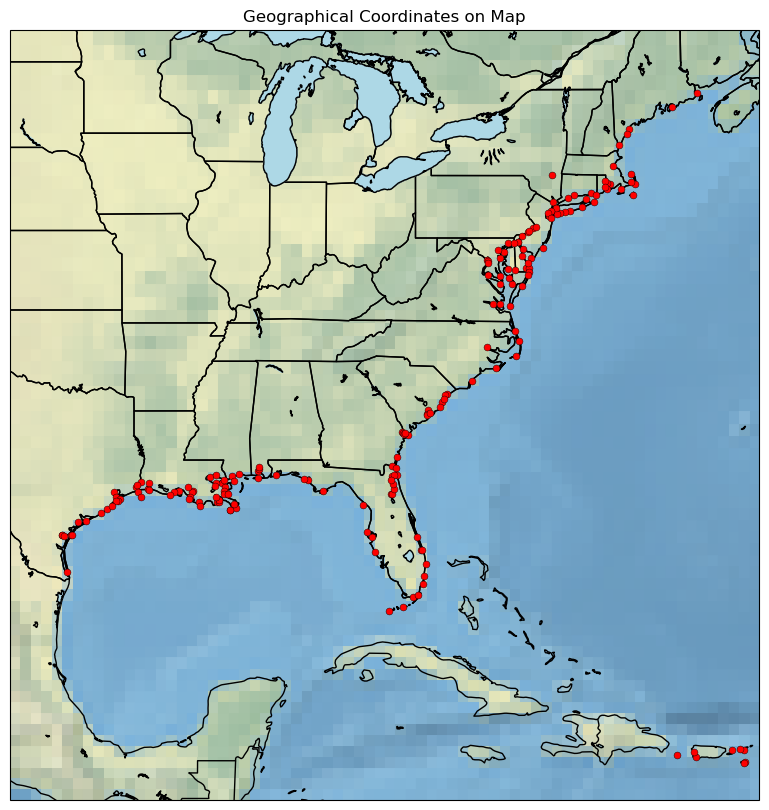

In [38]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature

unique_lats = df['y'].unique().tolist()
unique_longs = df['x'].unique().tolist()

def mapper():
    fig = plt.figure(figsize=(12, 10))
    ax = plt.axes(projection=ccrs.Mercator())
    
    # Adding features to the map
    ax.add_feature(cfeature.COASTLINE, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, edgecolor='black')
    ax.add_feature(cfeature.STATES, edgecolor='black')
    ax.set_extent([-100, -64, 16, 47], crs=ccrs.PlateCarree())

    # Setting map background color
    ax.stock_img()  # This adds a background image with natural features
    ax.add_feature(cfeature.LAND, color='0.8')  # Adding land with grey color
    ax.add_feature(cfeature.OCEAN, color='lightblue')  # Adding ocean with light blue color
    ax.add_feature(cfeature.LAKES, color='lightblue')  # Adding lakes with light blue color
    
    lake_borders = NaturalEarthFeature(category='physical', name='lakes', scale='10m', edgecolor='black', facecolor='none')
    ax.add_feature(lake_borders)
    
    return ax

ax = mapper()

# Converting coordinates for plotting
ax.scatter(unique_longs, unique_lats, marker='o', color='red', 
           edgecolors='black', linewidths=0.3, zorder=10, s=25, transform=ccrs.PlateCarree())

plt.title('Geographical Coordinates on Map')
plt.show()

## Train Test Split

### Clustering

In [39]:
unique_stations = df[['station_id', 'x', 'y']].drop_duplicates()
unique_df = pd.DataFrame(unique_stations, columns=['station_id', 'x', 'y'])

len(unique_df)

188

In [40]:
nclusters= int(len(unique_df)*0.1)

nclusters

18

In [41]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters= nclusters, random_state=42)
unique_df['cluster_id'] = kmeans.fit_predict(unique_df[['x','y']])

In [42]:
unique_df= unique_df.sort_values('cluster_id')

In [43]:
import matplotlib.colors as mcolors

cmap = plt.cm.get_cmap('Set1')
colors = [cmap(i) for i in range(8)]
colors_hex = [mcolors.rgb2hex(c) for c in colors]
 
cluster_colors = {cluster_id: colors_hex[cluster_id % 8] for cluster_id in unique_df['cluster_id']}
unique_df['color'] = unique_df['cluster_id'].map(cluster_colors)

In [44]:
unique_df.head(10)

,station_id,x,y,cluster_id,color
24048,8771367.0,-93.720001,29.469000,0,#e41a1c
23714,8771013.0,-94.914538,29.480000,0,#e41a1c
23881,8771341.0,-94.724800,29.357300,0,#e41a1c
24215,8771450.0,-94.793306,29.310924,0,#e41a1c
24382,8771486.0,-94.897083,29.302583,0,#e41a1c
24549,8771972.0,-95.113306,29.095000,0,#e41a1c
24716,8772985.0,-95.611401,28.764743,0,#e41a1c
23380,8770613.0,-94.985000,29.681815,0,#e41a1c
23547,8770822.0,-93.839780,29.689389,0,#e41a1c
23213,8770520.0,-93.881699,29.980777,0,#e41a1c


In [45]:
unique_df.dtypes

station_id     object
x             float64
y             float64
cluster_id      int32
color          object
dtype: object

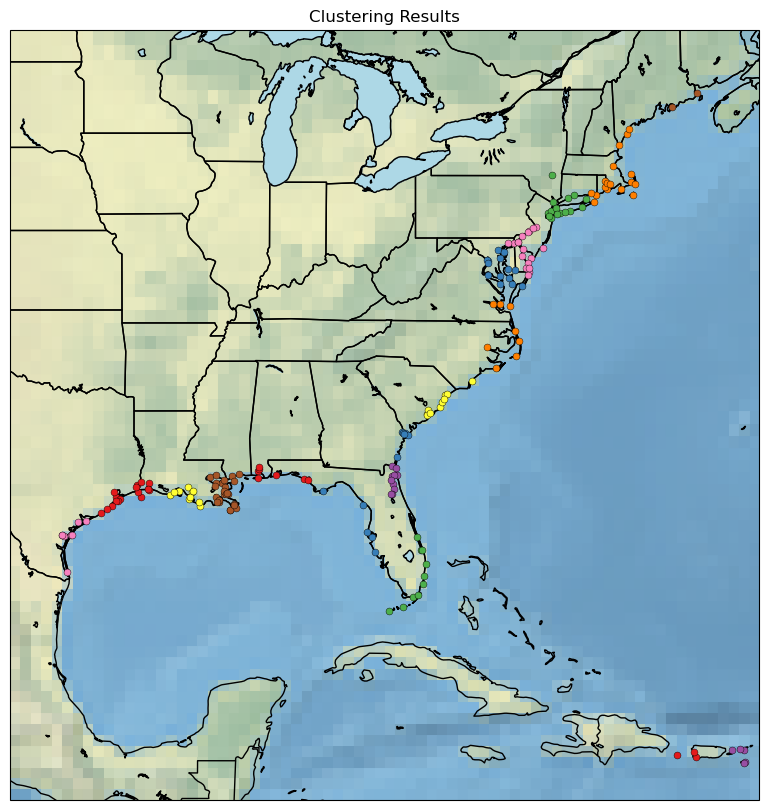

In [46]:
ax= mapper()

for i in range(len(unique_df)):
    x = unique_df['x'].iloc[i]
    y = unique_df['y'].iloc[i]
    ax.scatter(x, y, marker='o', color= unique_df['color'].iloc[i],
               edgecolors='black', linewidths=0.3, zorder= 10, s= 25, transform=ccrs.PlateCarree())    

plt.title('Clustering Results')
plt.show()

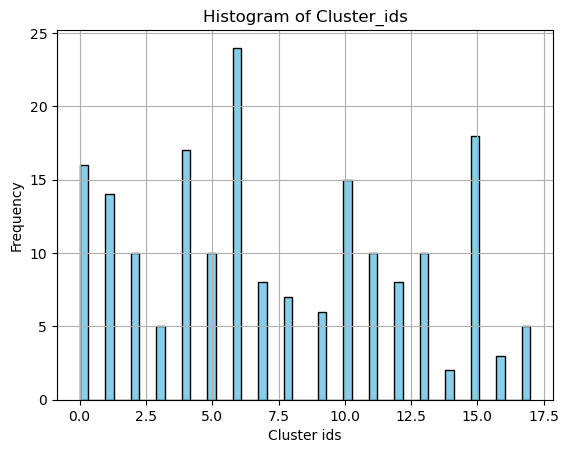

In [47]:
plt.hist(unique_df['cluster_id'], bins=53, color='skyblue', edgecolor='black')  
plt.xlabel('Cluster ids')
plt.ylabel('Frequency')
plt.title('Histogram of Cluster_ids')
plt.grid(True)
plt.show()

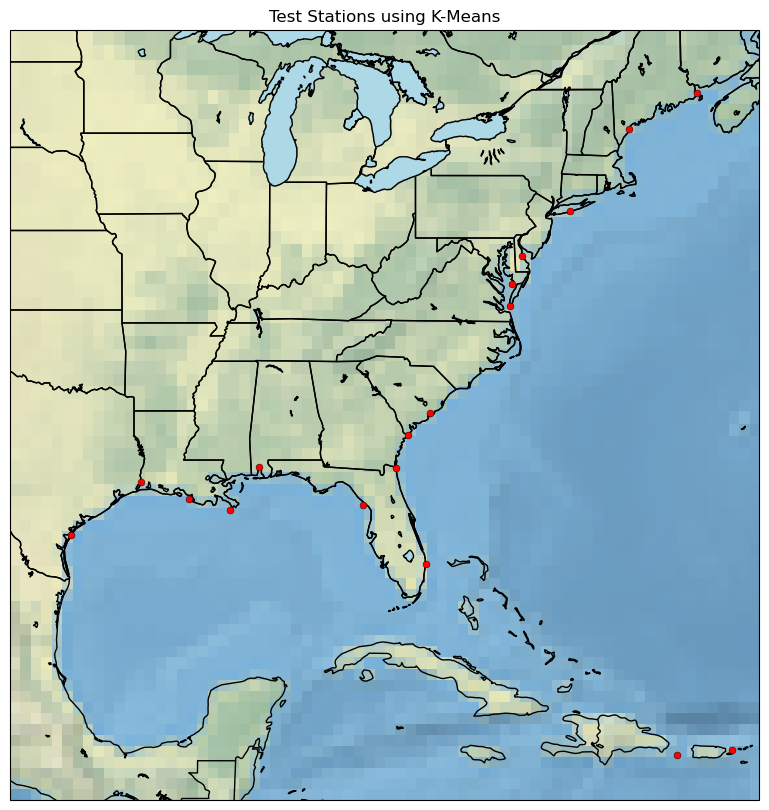

In [48]:
test_ids = []

grouped_df = unique_df.groupby('cluster_id')

for cluster_id, group in grouped_df:
    random_row = group.sample(1)
    new_station_id = random_row['station_id'].values[0]
    test_ids.append(new_station_id)

ax= mapper()
ktest_longs = []
ktest_lats= []

for i in test_ids:
    x, y= unique_df[unique_df['station_id']== i]['x'].values[0], unique_df[unique_df['station_id']== i]['y'].values[0]
    ktest_longs.append(x)
    ktest_lats.append(y)
    ax.scatter(x, y, marker='o', color= "red", 
               edgecolors='black', linewidths=0.3, zorder= 10, s= 25, transform=ccrs.PlateCarree())    

plt.title('Test Stations using K-Means')
plt.show()

In [49]:
station_counts = {}

for station_id in test_ids:
    count = df['station_id'].eq(station_id).sum()
    station_counts[station_id] = count
    
station_counts

{'8030540.0': 167,
 '1485755.0': 167,
 '8722670.0': 167,
 '9752235.0': 167,
 '8418150.0': 167,
 '217206962.0': 167,
 '8760922.0': 167,
 '8775237.0': 167,
 '8737048.0': 167,
 '8670870.0': 167,
 '1306402.0': 167,
 '8720030.0': 167,
 '8632200.0': 167,
 '8764314.0': 167,
 '8410140.0': 167,
 '1484085.0': 167,
 '9759938.0': 167,
 '8727520.0': 167}

In [50]:
test_df = df[df['x'].isin(ktest_longs)]
train_df = df[~df['x'].isin(ktest_longs)]

print(test_df['station_id'].nunique())
print(train_df['station_id'].nunique())

18
170


In [51]:
test_df.to_csv('test_df_filtered.csv', index=False)
train_df.to_csv('train_df_filtered.csv', index=False)

In [28]:
unique_df['cluster_id'].value_counts()

cluster_id
13    23
10    18
0     17
12    16
6     15
11    12
7     10
8     10
16     8
9      8
1      8
4      8
5      6
2      6
17     6
3      5
14     3
15     2
Name: count, dtype: int64